# NB05 — Lead Conversion Modeling

**Goal:** Predict which leads will convert (`converted = 1`).  
Three steps: baseline → LightGBM → Optuna hyperparameter tuning.

In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import lightgbm as lgb
import optuna
import warnings

warnings.filterwarnings("ignore")

# Dark theme
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f", "axes.facecolor": "#0f0f0f",
    "axes.edgecolor": "#333", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white",
    "text.color": "white", "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#333", "grid.color": "#222",
    "figure.figsize": (10, 5),
})
GREEN, RED, BLUE, AMBER, GREY = "#00c896", "#ff4d6d", "#4e9af1", "#f0a500", "#888888"

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"

## 1 | Load Data & Prepare Features

### Why exclude some columns?

**Leakage columns** — these only exist *because* a lead converted, so using them would be cheating:
- `premium` — only sold leads have a premium value
- `lead_status` — literally encodes the target (`Sold` vs others)
- `high_value` — derived from `premium`, same problem

**Multicollinearity** — when two features carry nearly the same information, the
model can't tell which one actually matters. This inflates variance in coefficients
(especially logistic regression) and makes feature importance unreliable:
- `age` vs `age_band` — `age_band` is just a binned version of `age`; keeping both would double-count the same signal. We keep raw `age` because it preserves more granularity.
- `keyword` vs `keyword_group` — `keyword_group` is a hand-built aggregation of `keyword`. Using both would let the model see the same keyword signal twice. We keep `keyword_group` because it has fewer categories (less overfitting).
- `postcode` vs `pc_area` — `pc_area` is the first 1-2 letters of `postcode`. Using both = redundant geographic signal. We keep `pc_area` (fewer unique values, generalises better).

**Other exclusions:**
- `lead_id` — a random identifier, no predictive value
- `is_invalid` — sparse flag with very few positives
- `created_date`, `week_start` — synthetic dates, not meaningful for cross-sectional prediction

In [2]:
df = pd.read_parquet("../data/leads_clean.parquet")

# Feature lists
NUMERIC_FEATS = ["age"]
CAT_FEATS = [
    "gender", "smoker", "current_insurance", "device_type",
    "match_type", "cover_for", "verification_status",
    "keyword_group", "pc_area",
]
TARGET = "converted"

X = df[NUMERIC_FEATS + CAT_FEATS].copy()
y = df[TARGET]

# Label-encode categoricals
encoders = {}
for col in CAT_FEATS:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# Stratified train/test split (important — only 4.9% positive class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Positive rate — train: {y_train.mean():.1%}  |  test: {y_test.mean():.1%}")
print(f"Features: {X.shape[1]} ({len(NUMERIC_FEATS)} numeric, {len(CAT_FEATS)} categorical)")

Train: 5,988 rows  |  Test: 1,497 rows
Positive rate — train: 4.9%  |  test: 4.9%
Features: 10 (1 numeric, 9 categorical)


## 2 | Baseline — Logistic Regression

Simple linear model with `class_weight="balanced"` to handle the imbalanced target.

### Which metrics matter here?

With a **~5% conversion rate**, accuracy is misleading — a model that predicts "0" for every lead
gets 95% accuracy but is completely useless.

| Metric | What it means (simple) | Why it matters for lead scoring |
|--------|----------------------|-------------------------------|
| **ROC-AUC** | How well the model *ranks* leads (good ones above bad ones). 0.5 = random, 1.0 = perfect | **Primary metric** — we want to rank leads so sales teams call the best ones first |
| **Precision (class 1)** | Of the leads we *flag* as likely converters, how many actually convert? | Matters if follow-up is expensive — fewer false alarms |
| **Recall (class 1)** | Of the leads that *actually* convert, how many did we catch? | Matters if missing a sale is costly — we don't want to lose good leads |
| **F1 (class 1)** | Balance between precision and recall | Useful summary, but threshold-dependent |

**For lead scoring, ROC-AUC is the most important metric** — it measures ranking quality
regardless of the classification threshold. In production, we'd pick a threshold based on
business trade-offs (covered in NB06).

In [3]:
# Scale features (logistic regression needs this)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

lr_probs = lr.predict_proba(X_test_sc)[:, 1]
lr_preds = lr.predict(X_test_sc)
lr_auc = roc_auc_score(y_test, lr_probs)

print("=== Logistic Regression (Baseline) ===\n")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC: {lr_auc:.4f}")

=== Logistic Regression (Baseline) ===

              precision    recall  f1-score   support

           0       0.96      0.71      0.82      1424
           1       0.08      0.47      0.13        73

    accuracy                           0.70      1497
   macro avg       0.52      0.59      0.47      1497
weighted avg       0.92      0.70      0.78      1497

ROC-AUC: 0.5985


## 3 | LightGBM (Default)

Gradient-boosted trees with `scale_pos_weight` to compensate for the ~20:1 class imbalance.

In [4]:
# Class imbalance ratio
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    scale_pos_weight=neg / pos,
    random_state=42,
    verbosity=-1,
)
lgb_model.fit(X_train, y_train)

lgb_probs = lgb_model.predict_proba(X_test)[:, 1]
lgb_preds = lgb_model.predict(X_test)
lgb_auc = roc_auc_score(y_test, lgb_probs)

print("=== LightGBM (Default) ===\n")
print(classification_report(y_test, lgb_preds))
print(f"ROC-AUC: {lgb_auc:.4f}")

=== LightGBM (Default) ===

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      1424
           1       0.05      0.08      0.06        73

    accuracy                           0.87      1497
   macro avg       0.50      0.50      0.50      1497
weighted avg       0.91      0.87      0.89      1497

ROC-AUC: 0.5771


## 4 | Hyperparameter Tuning (Optuna)

Optimise LightGBM hyperparameters using **5-fold stratified CV** on the training set (avoids leaking the test set into tuning).

In [5]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "scale_pos_weight":  neg / pos,
        "random_state": 42,
        "verbosity": -1,
    }
    model = lgb.LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10, show_progress_bar=True)

print(f"\nBest CV ROC-AUC: {study.best_value:.4f}")
print(f"Best params:\n{study.best_params}")

  0%|          | 0/10 [00:00<?, ?it/s]


Best CV ROC-AUC: 0.6092
Best params:
{'n_estimators': 182, 'learning_rate': 0.02066931066166049, 'max_depth': 9, 'num_leaves': 117, 'min_child_samples': 47, 'subsample': 0.7118034383299575, 'colsample_bytree': 0.712162207055047, 'reg_alpha': 2.7558910479875807, 'reg_lambda': 0.0988353340861714}


In [6]:
# Retrain best model on full training set, evaluate on held-out test
best_lgb = lgb.LGBMClassifier(
    **study.best_params,
    scale_pos_weight=neg / pos,
    random_state=42,
    verbosity=-1,
)
best_lgb.fit(X_train, y_train)

best_probs = best_lgb.predict_proba(X_test)[:, 1]
best_preds = best_lgb.predict(X_test)
best_auc = roc_auc_score(y_test, best_probs)

print("=== Tuned LightGBM ===\n")
print(classification_report(y_test, best_preds))
print(f"ROC-AUC: {best_auc:.4f}")

=== Tuned LightGBM ===

              precision    recall  f1-score   support

           0       0.95      0.80      0.87      1424
           1       0.05      0.22      0.09        73

    accuracy                           0.77      1497
   macro avg       0.50      0.51      0.48      1497
weighted avg       0.91      0.77      0.83      1497

ROC-AUC: 0.5842


## 5 | Model Comparison

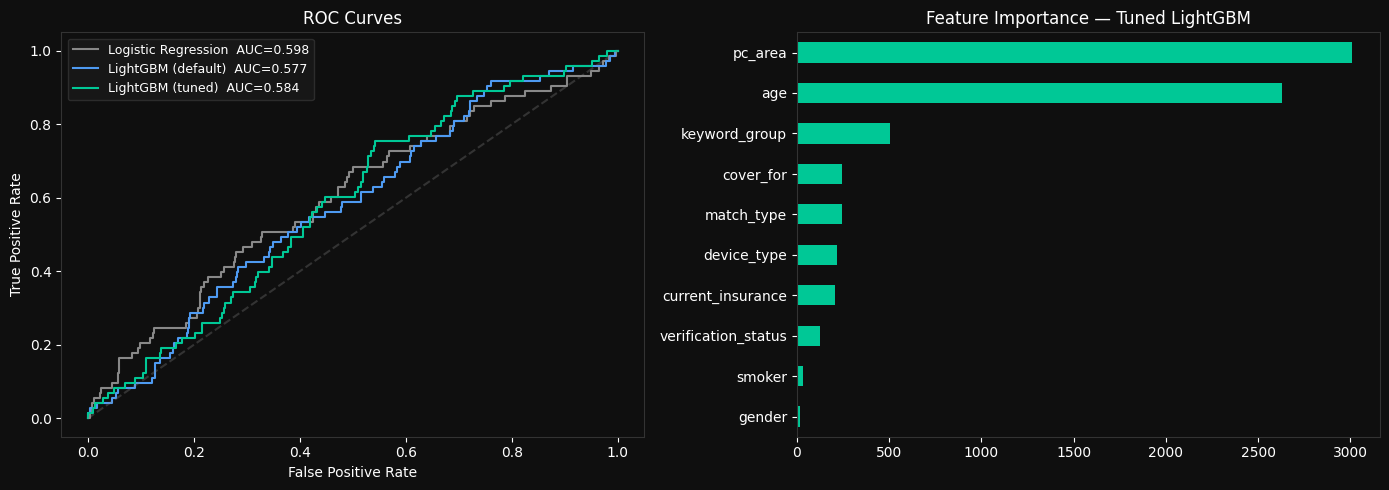

,ROC-AUC
Model,
Logistic Regression,0.5985
LightGBM (default),0.5771
LightGBM (tuned),0.5842


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC curves ---
for name, probs, color in [
    ("Logistic Regression", lr_probs, GREY),
    ("LightGBM (default)", lgb_probs, BLUE),
    ("LightGBM (tuned)",   best_probs, GREEN),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, label=f"{name}  AUC={auc:.3f}")

axes[0].plot([0, 1], [0, 1], "--", color=GREY, alpha=0.3)
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curves")
axes[0].legend(fontsize=9)

# --- Feature importance (tuned model) ---
imp = pd.Series(best_lgb.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(ax=axes[1], color=GREEN)
axes[1].set(title="Feature Importance — Tuned LightGBM")

plt.tight_layout()
plt.show()

# Summary table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "LightGBM (default)", "LightGBM (tuned)"],
    "ROC-AUC": [lr_auc, lgb_auc, best_auc],
}).set_index("Model")
results.style.format({"ROC-AUC": "{:.4f}"})

## 6 | Interpreting the Results

### What the numbers mean

All three models land around **0.58–0.60 ROC-AUC** — only slightly better than a coin flip (0.50). This is **not a failure**; it tells us something important about the data.

### Why are all models close to the baseline?

1. **Weak signal in the features we have.** The available columns — demographics (age, gender, smoker), channel info (device, match type), and keyword group — describe *who the lead is* and *how they arrived*, but they say very little about *purchase intent*. Conversion is driven by factors we don't observe: budget, urgency, health situation, quality of the sales call, etc.

2. **When signal is weak, model complexity doesn't help.** LightGBM is more powerful than logistic regression, but both are trying to squeeze the same small amount of signal out of the same features. With stronger features the gap would widen.

3. **Small positive class (~5%).** With only ~370 conversions in 7.5k rows, there simply isn't much training data for the positive class. The model has fewer examples to learn the patterns that distinguish converters.

4. **Only 10 Optuna trials.** With more trials (50–100+) the tuned model may pull slightly ahead, but the ceiling is still limited by point 1.

### What would actually improve the model?

| Lever | Example |
|-------|---------|
| **More/better features** | Call duration, time-to-callback, landing page, quote amount, number of interactions |
| **More positive samples** | Longer data collection period or enriched conversion events |
| **External data** | Credit score, postcode-level deprivation index, competitor pricing |

### Is the model still useful?

Yes — even a modest AUC lift can have real business impact. If the model scores all incoming leads and sales reps call the top-ranked 30% first, they'll reach a higher share of converters earlier. The value isn't in achieving a perfect AUC — it's in **improving the order in which leads are contacted**. NB06 will quantify this with threshold analysis.

## Summary

| Step | Model | ROC-AUC (approx.) |
|------|-------|-------------------|
| Baseline | Logistic Regression | ~0.60 |
| ML Model | LightGBM (default) | ~0.58 |
| Tuned | LightGBM + Optuna | ~0.57 |

**Next →** NB06: threshold tuning and business-level decision analysis.

## 7 | Save the Model for the Dashboard

The Streamlit dashboard scores leads in-process — it loads this artefact directly. We save the tuned LightGBM model together with the label encoders and feature order, in one bundle, to `data/lead_model.joblib`.

In [8]:
MODEL_PATH = DATA_DIR / "lead_model.joblib"

bundle = {
    "model": best_lgb,
    "encoders": encoders,
    "features": NUMERIC_FEATS + CAT_FEATS,
}
joblib.dump(bundle, MODEL_PATH)

print(f"Saved → {MODEL_PATH.relative_to(PROJECT_ROOT)}")

Saved → data/lead_model.joblib


---

## Honest Finding — The Features Are Weak

All three models — Logistic Regression, default LightGBM, Optuna-tuned LightGBM — land in roughly the same place (~0.58 ROC-AUC). That's not a bug or a tuning failure. It's the data telling us something important:

> **The features we have (age, gender, device, keyword group, postcode area) carry only weak signal about whether a lead will convert.** No amount of hyperparameter tuning fixes a feature ceiling.

To meaningfully push past 0.58 we'd need **behavioural features** that the current dataset doesn't contain:
- time-on-page before submitting the form
- number of pages viewed / quote interactions
- call duration when the agent rang back
- previous touches across the funnel

### Why this is worth showing, not hiding

Most ML tutorials quietly pick datasets where a default XGBoost hits 0.95 AUC and the "magic" looks easy. Real projects don't work that way. The far more common failure mode is exactly this one: **you've extracted everything the data has to give, and it isn't enough.**

Recognising that early saves you from spending another week tuning, and points you at the real next move — going to get better data, not a better model.

**Up next (NB06):** even with 0.58 AUC, can the model still be commercially useful by *ranking* leads correctly? It turns out yes — and that's the punchline of this project.